The purpose of this notebook is to plot paleo and modern observations for the introduction slides.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from hydra import initialize, compose
from pathlib import Path
from methane_noise_forcing.plotting.constants import matplotlib_rcparams, colors_vibrant, fig_width_options
from methane_noise_forcing import io
from methane_noise_forcing import detrend_obs
plt.rcParams.update(matplotlib_rcparams)

In [65]:
with initialize(version_base=None, config_path="../../configs"):  # configs with data paths
    cfg = compose(config_name="config")
data_dir = Path(cfg.paths.observations_cultivated)
# modern
obs_modern = pd.read_csv(data_dir / "ch4_modern_detrended.csv")

# paleo
site_name = 'wdc06a'
obs_paleo = io.load_observational_data(site_name, **cfg.io[site_name].input)

2025-09-30 19:27:52,606 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv


In [68]:
# get linear fits to data
coeffs_modern = np.polyfit(obs_modern['year'], obs_modern['ch4'], 1)
coeffs_paleo = np.polyfit(obs_paleo['gas_age'], obs_paleo['ch4'], 1)

# detrend paleo data
obs_paleo_detrended = detrend_obs(site_name, obs_paleo)

# add detrended data to dataframe
obs_paleo['ch4_detrended'] = obs_paleo_detrended["ch4"]

2025-09-30 19:28:14,208 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2


In [4]:
# file naming for flags
def generate_figure_name(name_base, plot_toggles):
    """
    Generate a figure name based on the toggled plot options.
    
    Adds suffixes if certain plot options are NOT enabled
    """
    for key, value in plot_toggles.items():
        if not value:
            key_clean = key.replace("plot_", "no_")
            name_base += f"-{key_clean}"
    return name_base

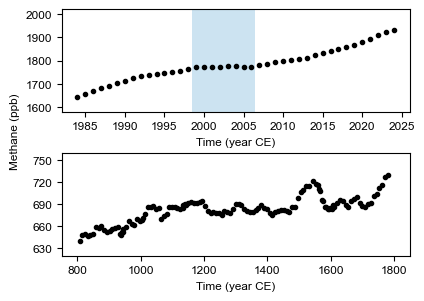

In [ ]:
## plot modern and paleo
## params
plot_toggles = {
    "plot_trend_lines": False,
    "plot_acceleration_period": False,
    "plot_hiatus_period": True,
}
# modern
xlims_modern = (1982, 2026)
ylims_modern = (1580, 2020)
yticks_modern = np.arange(1600, 2001, 100)
xlim_hiatus = (1998.5, 2006.5)
xlim_acceleration = (2020.5, 2022.5)

# paleo
x_min_paleo = 800
x_max_paleo = 1800
xlims_paleo = (750, 1850)
ylims_paleo = (620, 760)
yticks_paleo = np.arange(630, 751, 30)
time_mask_paleo = (obs_paleo['gas_age'] >= x_min_paleo) & (obs_paleo['gas_age'] <= x_max_paleo)

plot_kwargs = {
    "data": {
        "color": "k",
        "linestyle": "None",
        "marker": ".",
        "markersize": 6,
        },
    "shading": {
        "color": colors_vibrant['blue'],
        "alpha": 0.2,
    },
}

fig = plt.figure(figsize=(fig_width_options["two_column_small"], 2 * 1.6))
gs = GridSpec(
    nrows=2,
    ncols=1,
    figure=fig,
    hspace=0.4,
)

## top plot: methane
ax_modern = fig.add_subplot(gs[0])
ax_modern.plot(
    obs_modern['year'],
    obs_modern['ch4'],
    label='Modern observations',
    **plot_kwargs['data'],
)
if plot_toggles['plot_trend_lines']:
    ax_modern.plot(
        [1970, 2030],
        np.polyval(coeffs_modern, [1970, 2030]),
        color=colors_vibrant['red'],
        linestyle='-.',
        alpha=0.7,
        label='Linear trend',
    )
if plot_toggles['plot_hiatus_period']:
    ax_modern.axvspan(*xlim_hiatus, **plot_kwargs['shading'], label='Hiatus period', ls='None')
if plot_toggles['plot_acceleration_period']:
    ax_modern.axvspan(*xlim_acceleration, **plot_kwargs['shading'], label='Acceleration period', ls='None')
ax_modern.set_ylim(ylims_modern)
ax_modern.set_yticks(yticks_modern)
ax_modern.set_xlim(xlims_modern)
ax_modern.set_xlabel('Time (year CE)')

## bottom plot: paleo
obs_paleo_plot = obs_paleo[time_mask_paleo]
ax_paleo = fig.add_subplot(gs[1])
ax_paleo.plot(
    obs_paleo_plot['gas_age'],
    obs_paleo_plot['ch4'],
    label='Paleo observations',
    **plot_kwargs['data'],
)
ax_paleo.set_ylim(ylims_paleo)
ax_paleo.set_yticks(yticks_paleo)
ax_paleo.set_xlim(xlims_paleo)
ax_paleo.set_xlabel('Time (year CE)')

fig.text(0.01, 0.5, "Methane (ppb)", va="center", rotation="vertical")

name = generate_figure_name("intro_obs", plot_toggles)
fig.savefig(
    f"{cfg.paths.figures_dir}/figures_for_seminar/{name}.pdf", bbox_inches="tight", dpi=300
)

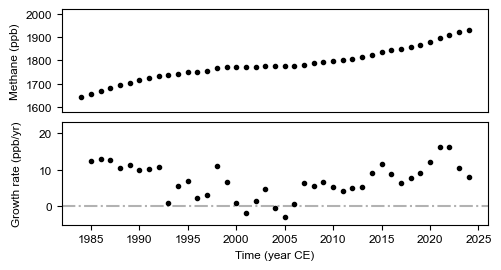

In [123]:
## plot modern and growth rate
## params
plot_toggles = {
    "plot_trend_lines": False,
    "plot_acceleration_period": False,
    "plot_hiatus_period": False,
}
# modern
xlims_modern = (1982, 2026)
ylims_modern = (1580, 2020)
yticks_modern = np.arange(1600, 2001, 100)
xlim_hiatus = (1998.5, 2006.5)
xlim_acceleration = (2020.5, 2022.5)

# paleo
ylims_detrended = (-5, 23)

plot_kwargs = {
    "data": {
        "color": "k",
        "linestyle": "None",
        "marker": ".",
        "markersize": 6,
        },
    "shading": {
        "color": colors_vibrant['blue'],
        "alpha": 0.2,
    },
}

fig = plt.figure(figsize=(
    # fig_width_options["two_column_small"], 
    5.5,
    2 * 1.4
    ))
gs = GridSpec(
    nrows=2,
    ncols=1,
    figure=fig,
    hspace=0.1,
)

## top plot: methane
ax_modern = fig.add_subplot(gs[0])
ax_modern.plot(
    obs_modern['year'],
    obs_modern['ch4'],
    label='Modern observations',
    **plot_kwargs['data'],
)
if plot_toggles['plot_trend_lines']:
    ax_modern.plot(
        [1970, 2030],
        np.polyval(coeffs_modern, [1970, 2030]),
        color=colors_vibrant['red'],
        linestyle='-.',
        alpha=0.7,
        label='Linear trend',
    )
if plot_toggles['plot_hiatus_period']:
    ax_modern.axvspan(*xlim_hiatus, **plot_kwargs['shading'], label='Hiatus period', ls='None')
if plot_toggles['plot_acceleration_period']:
    ax_modern.axvspan(*xlim_acceleration, **plot_kwargs['shading'], label='Acceleration period', ls='None')
ax_modern.set_ylim(ylims_modern)
ax_modern.set_yticks(yticks_modern)
ax_modern.set_xlim(xlims_modern)
ax_modern.set_xticks([])
ax_modern.set_ylabel("Methane (ppb)")

## bottom plot: growth rate
obs_modern_growth = obs_modern['ch4'].diff(periods=1)
ax_modern_growth = fig.add_subplot(gs[1])
ax_modern_growth.plot(
    obs_modern['year'],
    obs_modern_growth,
    label='Modern growth rate',
    **plot_kwargs['data'],
)
if plot_toggles['plot_hiatus_period']:
    ax_modern_growth.axvspan(*xlim_hiatus, **plot_kwargs['shading'], label='Hiatus period', ls='None')
if plot_toggles['plot_acceleration_period']:
    ax_modern_growth.axvspan(*xlim_acceleration, **plot_kwargs['shading'], label='Acceleration period', ls='None')
ax_modern_growth.set_xlim(xlims_modern)
ax_modern_growth.set_ylim(ylims_detrended)
ax_modern_growth.axhline(0, color='k', linestyle='-.', alpha=0.3)
ax_modern_growth.set_ylabel("Growth rate (ppb/yr)", labelpad=12)
ax_modern_growth.set_xlabel('Time (year CE)')

name = generate_figure_name("intro_growth_rate", plot_toggles)
fig.savefig(
    f"{cfg.paths.figures_dir}/figures_for_seminar/{name}.pdf", bbox_inches="tight", dpi=300
)

In [ ]:
## plot modern and change in methane (absolute, detrended)

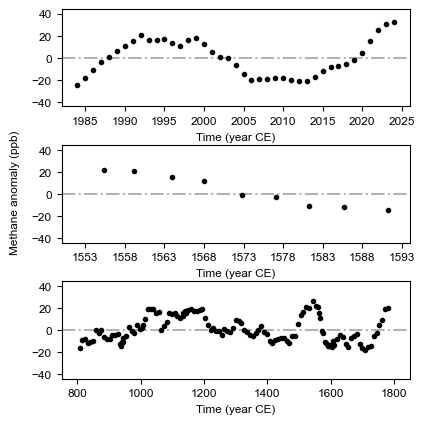

In [95]:
## plot modern detrended, paleo detrended zoom, and paleo detrended
## params
plot_toggles = {
    "plot_acceleration_period": False,
    "plot_hiatus_period": False,
    "plot_zoomed_paleo_shading": False,
}
# modern
xlims_modern = (1982, 2026)
xticks_modern = np.arange(1985, 2026, 5)
ylims_modern = (-44, 44)
yticks_modern = np.arange(-40, 41, 20)
xlim_hiatus = (1998.5, 2006.5)
xlim_acceleration = (2020.5, 2022.5)

# zoom-in
period_length = 44
x_min_zoom = 1550
x_max_zoom = x_min_zoom + period_length
xlims_zoom = (x_min_zoom, x_max_zoom)
xticks_zoom = np.arange(x_min_zoom + 3, x_max_zoom + 1, 5)
time_mask_zoom = (obs_paleo['gas_age'] >= x_min_zoom) & (obs_paleo['gas_age'] <= x_max_zoom)

# paleo
x_min_paleo = 800
x_max_paleo = 1800
xlims_paleo = (750, 1850)
ylims_paleo = (620, 760)
yticks_paleo = np.arange(630, 751, 30)
time_mask_paleo = (obs_paleo['gas_age'] >= x_min_paleo) & (obs_paleo['gas_age'] <= x_max_paleo)

plot_kwargs = {
    "data": {
        "color": "k",
        "linestyle": "None",
        "marker": ".",
        "markersize": 6,
        },
    "shading": {
        "color": colors_vibrant['blue'],
        "alpha": 0.2,
    },
}

fig = plt.figure(figsize=(fig_width_options["two_column_small"], 3 * 1.6))
gs = GridSpec(
    nrows=3,
    ncols=1,
    figure=fig,
    hspace=0.4,
)

## top plot: methane detrended
ax_modern_detrended = fig.add_subplot(gs[0])
ax_modern_detrended.plot(
    obs_modern['year'],
    obs_modern['ch4_detrended'],
    **plot_kwargs['data'],
)
if plot_toggles['plot_hiatus_period']:
    ax_modern_detrended.axvspan(*xlim_hiatus, **plot_kwargs['shading'], label='Hiatus period', ls='None')
if plot_toggles['plot_acceleration_period']:
    ax_modern_detrended.axvspan(*xlim_acceleration, **plot_kwargs['shading'], label='Acceleration period', ls='None')
ax_modern_detrended.axhline(0, color='k', linestyle='-.', alpha=0.3)
ax_modern_detrended.set_xlim(xlims_modern)
ax_modern_detrended.set_ylim(ylims_modern)
ax_modern_detrended.set_yticks(yticks_modern)
ax_modern_detrended.set_xticks(xticks_modern)
ax_modern_detrended.set_xlabel('Time (year CE)')

## middle plot: paleo detrended zoom
obs_paleo_zoom = obs_paleo[time_mask_zoom]
ax_paleo_zoom = fig.add_subplot(gs[1])
ax_paleo_zoom.plot(
    obs_paleo_zoom['gas_age'],
    obs_paleo_zoom['ch4_detrended'],
    label='Paleo observations',
    **plot_kwargs['data'],
)
ax_paleo_zoom.axhline(0, color='k', linestyle='-.', alpha=0.3)
ax_paleo_zoom.set_xlim(xlims_zoom)
ax_paleo_zoom.set_xticks(xticks_zoom)
ax_paleo_zoom.set_ylim(ylims_modern)
ax_paleo_zoom.set_yticks(yticks_modern)
ax_paleo_zoom.set_xlabel('Time (year CE)')

## bottom plot: paleo detrended
obs_paleo_plot = obs_paleo[time_mask_paleo]
ax_paleo = fig.add_subplot(gs[2])
ax_paleo.plot(
    obs_paleo_plot['gas_age'],
    obs_paleo_plot['ch4_detrended'],
    label='Paleo observations',
    **plot_kwargs['data'],
)
ax_paleo.axhline(0, color='k', linestyle='-.', alpha=0.3)
if plot_toggles['plot_zoomed_paleo_shading']:
    ax_paleo.axvspan(*xlims_zoom, **plot_kwargs['shading'], label='Zoomed period', ls='None')
ax_paleo.set_ylim(ylims_modern)
ax_paleo.set_yticks(yticks_modern)
ax_paleo.set_xlim(xlims_paleo)
ax_paleo.set_xlabel('Time (year CE)')

fig.text(0.01, 0.5, "Methane anomaly (ppb)", va="center", rotation="vertical")

name = generate_figure_name("intro_detrended", plot_toggles)
fig.savefig(
    f"{cfg.paths.figures_dir}/figures_for_seminar/{name}.pdf", bbox_inches="tight", dpi=300
)

In [63]:
obs_paleo_plot

,gas_age,ch4
0,1780.7,20.261518
1,1771.2,18.930715
2,1763.2,8.682366
3,1754.1,5.046785
4,1745.5,-2.866581
...,...,...
119,840.7,-10.731713
120,832.0,-11.566466
121,824.0,-7.652663
122,815.1,-9.172969
